In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d import Axes3D
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# Añadir ruta local si es necesario (ajustar según tu estructura)
sys.path.append(r'c:/Users/sebas/MalariaProject/src')
#sys.path.append(r'c:/Users/sebas/MalariaProject//home/sgaviria/MalariaProject')

sys.path.append('/home/sgaviria/MalariaProject/')

from src import *

# Configuración de estilo para plots
#plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['font.size'] = 11

print("✅ Módulos importados correctamente")

✅ Módulos importados correctamente


In [5]:
archivo = "beta-hematina.txt"

data_txt = pd.read_csv(archivo, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])

#times = np.linspace(0, 300, 20)
times_txt = np.array(data_txt['Tiempo'])
all_times = np.array(list(set(times_txt/5) | set(times_txt/4) | set(times_txt/2) | set(times_txt)))

times = times_txt

In [34]:
times = np.arange(0, 151, 1)

In [53]:
times

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
       3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. ])

In [4]:
# sigmas = np.linspace(1, 8, 80)
sigmas = np.arange(1, 8.2, 0.2)

In [29]:
sigmas

array([1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4, 2.6, 2.8, 3. , 3.2, 3.4,
       3.6, 3.8, 4. , 4.2, 4.4, 4.6, 4.8, 5. , 5.2, 5.4, 5.6, 5.8, 6. ,
       6.2, 6.4, 6.6, 6.8, 7. , 7.2, 7.4, 7.6, 7.8, 8. ])

In [40]:
def compute_probabilities(sigmas, times, delta, size=(75, 75), mode="flat", n_seeds=1):

    prob_sta = []
    kmcs = []
    snaps_list = []

    # L = LatticeSOS_v2(size=size, seed=42)
    # # L.initialize(mode="random", max_height=1, n_seeds=1905)
    # L.initialize(mode=mode)

    for sigma in sigmas:
        print(f"\n\n=== σ = {sigma} ===")

        L = LatticeSOS_v2(size=size, seed=42+int(sigma))
        # L.initialize(mode="random", max_height=1, n_seeds=1905)
        L.initialize(mode=mode, max_height=0, n_seeds=n_seeds)

        params = KMCParams_v2(
        K0_plus= 2.116718e-13, #0.211,
        E_pb_over_kT= 1.2704636027368605, #.48,
        phi_over_kT= 1.792478012079329, #3.76,
        delta=delta,
        V=1,
        C_eq=15.0,
        fixed_sigma=sigma,   # usa un valor como 3.0 si quieres sigma estático
        S_floor=-5.0,
        S_ceil=9.0,
        )

        kmc = KMC_BKL_v2(
            lattice=L,
            params=params,
            N_bulk0=1000,
            rng_seed=123,
            time_scale=2,
            n_seeds=n_seeds,
            constant_concentration=True,  # batch dinámico
        )
        kmcs.append(kmc)

        snaps, stats = kmc.run(t_end=times[-1], snapshot_times=times)
        snaps_list.append(snaps)

        prob_sta.append(stats['adsorption_probs_history'])

        print(f"Datos para σ = {sigma} guardados.\n")

    return prob_sta, kmcs, snaps_list

In [31]:
# ============================================
# Extraer p0, p1, p2 desde prob_sta
# ============================================

def extraer_probs_desde_prob_sta(prob_sta):
    # Devuelve probabilidades promedio en la cola temporal para cada sigma
    p0, p1, p2 = [], [], []
    sigmas_plot = []

    for hist in prob_sta:
        # Si no hay historial para ese sigma, guardar NaN
        if len(hist) == 0:
            p0.append(np.nan); p1.append(np.nan); p2.append(np.nan); sigmas_plot.append(np.nan)
            continue

        # Sigma asociado a esa corrida (constante en esa historia)
        sigmas_plot.append(float(hist[-1][1]))

        # Tomar la cola temporal para aproximar estado cuasi-estacionario
        #n = len(hist)
        #k0 = max(0, int((1.0 - frac_tail) * n))
        tail = hist[:]

        vals0, vals1, vals2 = [], [], []
        for _, _, probs in tail:
            vals0.append(float(probs.get(0, 0.0)))
            vals1.append(float(probs.get(1, 0.0)))
            vals2.append(float(probs.get(2, 0.0)))

        # Promedio por sigma
        p0.append(np.mean(vals0) if len(vals0) else np.nan)
        p1.append(np.mean(vals1) if len(vals1) else np.nan)
        p2.append(np.mean(vals2) if len(vals2) else np.nan)

    return np.array(sigmas_plot), np.array(p0), np.array(p1), np.array(p2)

In [78]:
def plot_probs_vs_sigma(sigmas_plot, p0, p1, p2, path=None):
    # Ordenar por sigma por seguridad (por si llegan desordenados)
    idx = np.argsort(sigmas_plot)
    sigmas_plot = sigmas_plot[idx]
    p0 = p0[idx]
    p1 = p1[idx]
    p2 = p2[idx]

    # ============================================
    # Gráfica
    # ============================================
    fig, ax = plt.subplots()
    plt.gca().set_facecolor("#e9e9e9")

    # Regiones de régimen
    # ax.axvspan(1.0, 2.5, alpha=0.1, color='gold')
    # ax.axvspan(2.5, 6.0, alpha=0.1, color='orange')
    # ax.axvspan(6.0, 8.0, alpha=0.1, color='green')

    # ax.text(1.8, 0.52, 'SPIRAL', fontsize=11, ha='center', fontweight='bold', color='darkgoldenrod')
    # ax.text(4.25, 0.52, 'STEP', fontsize=11, ha='center', fontweight='bold', color='darkorange')
    # ax.text(7.0, 0.52, 'ROUGH', fontsize=11, ha='center', fontweight='bold', color='darkgreen')

    # Curvas de probabilidad extraídas desde prob_sta
    plt.plot(sigmas_plot, p0, color="#0072BD", linewidth=2.5, label='adatom (i = 0)')
    plt.plot(sigmas_plot, p1, color="#D95319", linewidth=2.5, label='step (i = 1)')
    plt.plot(sigmas_plot, p2, color="#EDB120", linewidth=2.5, label='kink (i = 2)')

    plt.xlim(1, 8)
    plt.ylim(0, 1)
    plt.xlabel("Sobresaturación (σ)")
    plt.ylabel("Probabilidad")
    plt.title("Probabilidades por sitio de adsorción")
    plt.legend()

    ax.tick_params(
        axis='both',
        which='both',
        direction='in',
        top=True,
        right=True
    )
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    plt.grid(False)
    if path:
        plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()

In [8]:
print(f"{(2820/40000)*100} %")

7.049999999999999 %


In [19]:
0.07*5625

393.75000000000006

In [18]:
75*75

5625



=== σ = 1.0 ===
Datos para σ = 1.0 guardados.



=== σ = 1.2 ===
Datos para σ = 1.2 guardados.



=== σ = 1.4 ===
Datos para σ = 1.4 guardados.



=== σ = 1.5999999999999999 ===
Datos para σ = 1.5999999999999999 guardados.



=== σ = 1.7999999999999998 ===
Datos para σ = 1.7999999999999998 guardados.



=== σ = 1.9999999999999998 ===
Datos para σ = 1.9999999999999998 guardados.



=== σ = 2.1999999999999997 ===
Datos para σ = 2.1999999999999997 guardados.



=== σ = 2.3999999999999995 ===
Datos para σ = 2.3999999999999995 guardados.



=== σ = 2.5999999999999996 ===
Datos para σ = 2.5999999999999996 guardados.



=== σ = 2.8 ===
Datos para σ = 2.8 guardados.



=== σ = 2.9999999999999996 ===
Datos para σ = 2.9999999999999996 guardados.



=== σ = 3.1999999999999993 ===
Datos para σ = 3.1999999999999993 guardados.



=== σ = 3.3999999999999995 ===
Datos para σ = 3.3999999999999995 guardados.



=== σ = 3.5999999999999996 ===
Datos para σ = 3.5999999999999996 guardados.



=== σ = 3.79

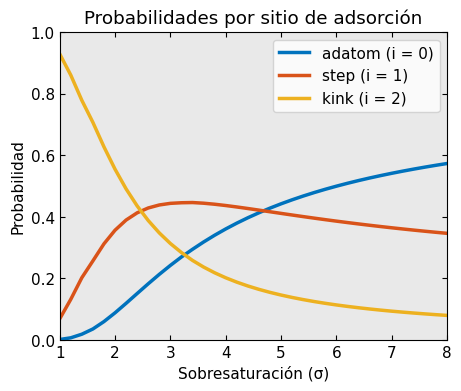

In [327]:
prob_sta, kmcs, snaps_list = compute_probabilities(sigmas, times, delta=4.18, size=(75, 75), mode="flat", n_seeds=126)
sigmas_plot, p0, p1, p2 = extraer_probs_desde_prob_sta(prob_sta)
plot_probs_vs_sigma(sigmas_plot, p0, p1, p2, path = "probabilidades_vs_sigma_75_126_418.png")
#plot_probs_vs_sigma(sigmas_plot, p0, p1, p2)

In [8]:
35*35

1225

In [12]:
kmcs

In [14]:
kmc0 = kmcs[0]
A_Bins_0 = kmc0._classify_adsorption_sites()

In [16]:
for i in range(5):
    print(f"{i}: {len(A_Bins_0[i])}")

0: 805
1: 334
2: 84
3: 2
4: 0


In [62]:
plotter = Plotter_v2(kmcs[0])

🧩 Snapshot seleccionado: t=1.000
💾 Imagen guardada en: crystal_growth.png


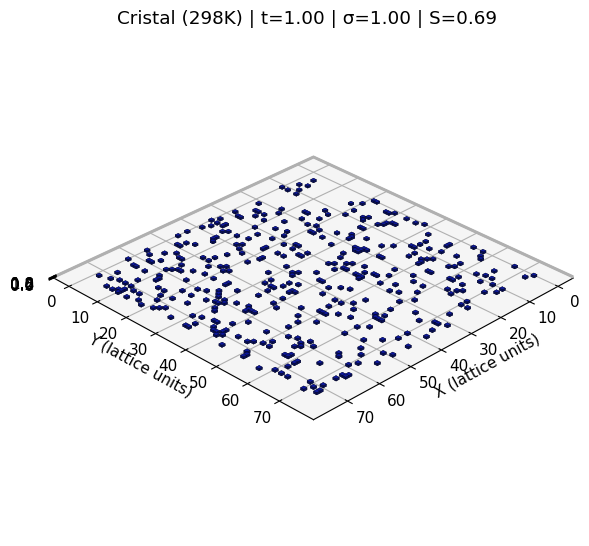

In [66]:
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_list[0],
    t_snapshot=times[len(times)- 150],
    save_path="crystal_growth.png",
)

KeyboardInterrupt: 

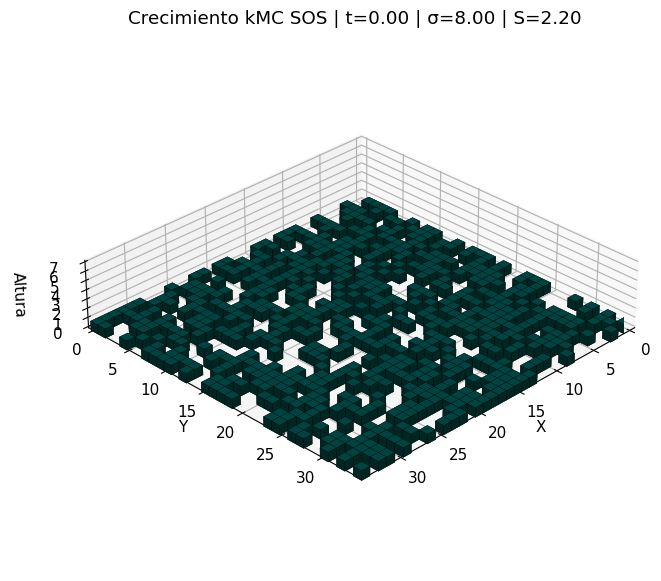

In [13]:
plotter.crystal_growth_gif(
    snapshots=snaps_list[5],
    save_path="crystal_growth_25.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento kMC SOS",
    every_n=1,
)

In [236]:
times = np.arange(0, 10, 1)

L = LatticeSOS_v2(size=(55, 55), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L.initialize(mode="flat", max_height=0)

params = KMCParams_v2(
K0_plus= 0.2116718, #0.211,
E_pb_over_kT= 2.2704636027368605, #.48,
phi_over_kT= 1.3792478012079329, #3.76,
delta=1,
V=1,
C_eq=15.0,
fixed_sigma=8,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc = KMC_BKL_v2(
    lattice=L,
    params=params,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=50,
    n_seeds=524,
    constant_concentration=True,  # batch dinámico
)

In [237]:
snaps, stats = kmc.run(t_end=times[-1], snapshot_times=times)

🧩 Snapshot seleccionado: t=9.000
💾 Imagen guardada en: crystal_growth_prueba.png


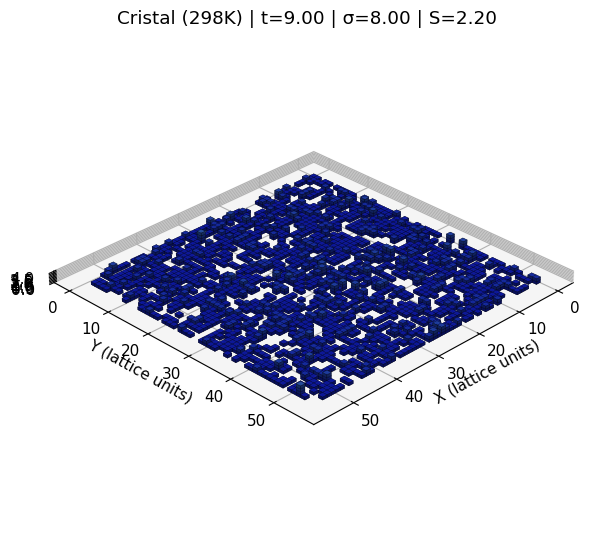

In [239]:
plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps,
    t_snapshot=times[len(times)-1],
    save_path="crystal_growth_prueba_4.png",
)

In [147]:
A_bins = kmc._classify_adsorption_sites()

In [142]:
A_bins_1 = kmc._classify_adsorption_sites()

In [143]:
for i in range(3):
    print(f"{i}: {len(A_bins_1[i])}")

0: 549
1: 357
2: 227


In [148]:
for i in range(3):
    print(f"{i}: {len(A_bins[i])}")

0: 831
1: 351
2: 42


KeyboardInterrupt: 

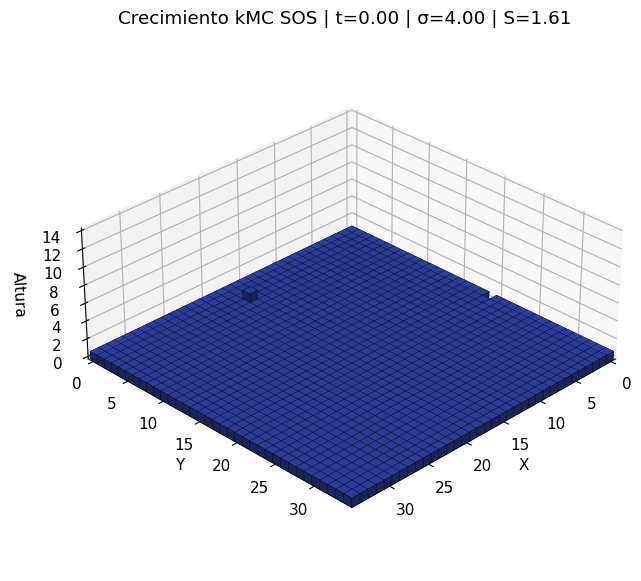

In [133]:
plotter.crystal_growth_gif(
    snapshots=snaps,
    save_path="crystal_growth_prueba_g4.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento kMC SOS",
    every_n=1,
)

In [20]:
35*35

1225